# Customer Segmentation

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_AI_Engineering/portfolio-10.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>

**Objective**: Use *k*-Means Clustering algorithm for customer segmentation.

[*k*-Means Clustering](https://en.wikipedia.org/wiki/K-means_clustering) is an unsupervised machine learning algorithm used for partitioning data into *k* clusters based on their similarities. It’s a centroid-based algorithm, meaning that each cluster is represented by a central point, called the centroid or mean.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Load the dataset

In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv"
df = pd.read_csv(file_url)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


## Understand the dataset

[Customer segmentation](https://en.wikipedia.org/wiki/Market_segmentation) is the practice of dividing a customer base into groups of individuals that have similar characteristics. It is a significant strategy because a business can target these specific customer groups and effectively allocate marketing resources. For example, one group might contain high-profit and low-risk customers, those who are more likely to purchase products or subscribe to a service. A business task is to retain those customers.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


## Visualize the dataset

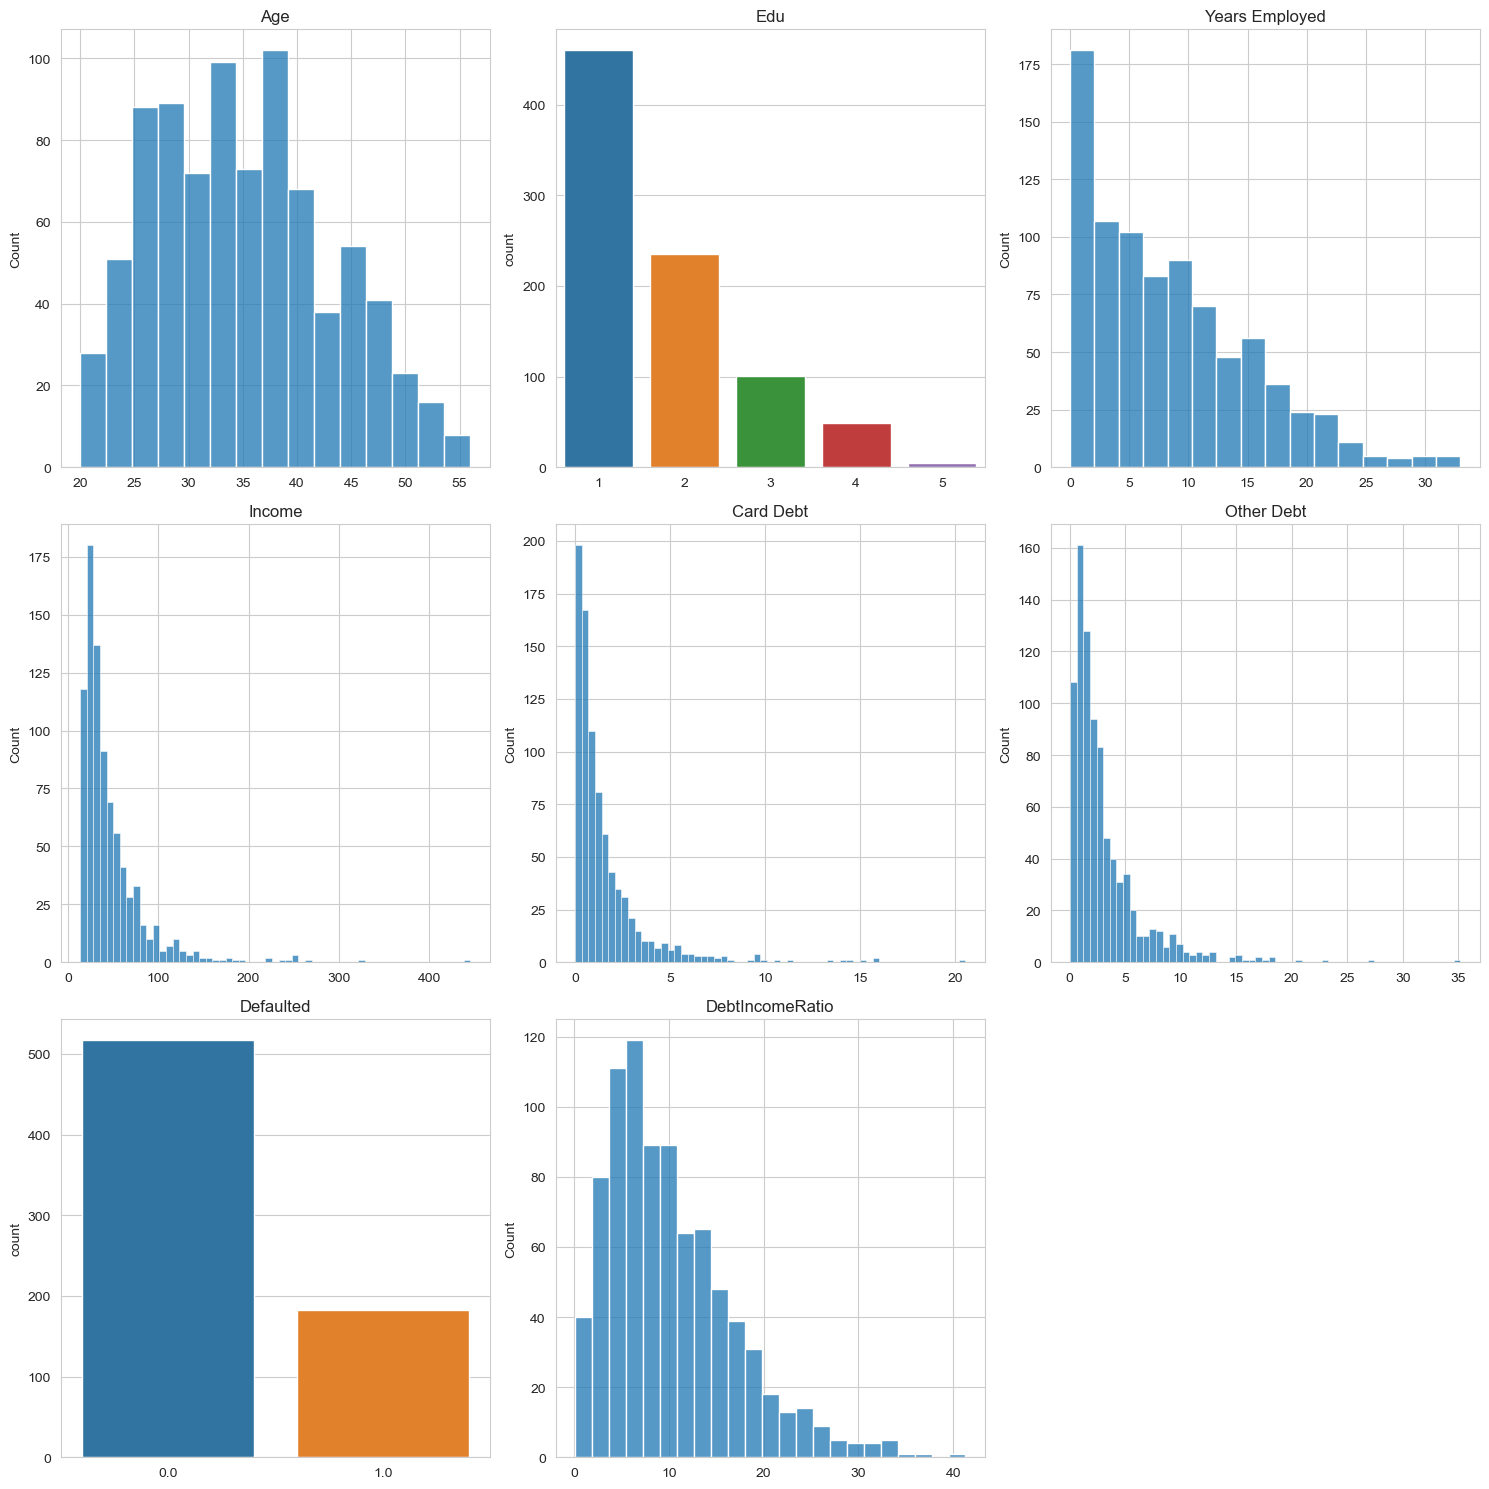

In [4]:
number_features = len(df.columns) - 2
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.drop(["Customer Id", "Address"], axis=1).columns):
    if len(df[feature].unique()) <= 10:
        sns.countplot(data=df, x=feature, hue=feature, ax=ax, palette="tab10", legend=False)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preprocess the dataset

In [5]:
df = df.drop(["Customer Id", "Address"], axis=1)
df = df.fillna(0)

## Compute *k*-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


## Visualize the clusters

In [7]:
df["Label"] = kmeans.labels_
df.groupby("Label").mean()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Label,,,,,,,,
0,32.964561,1.614792,6.374422,31.164869,1.032541,2.104133,0.237288,10.094761
1,45.388889,2.666667,19.555556,227.166667,5.678444,10.907167,0.222222,7.322222
2,41.333333,1.956284,15.256831,83.928962,3.103639,5.765279,0.136612,10.724590


The customers in each cluster are similar to each other demographically. Now we can create a profile for each group, considering the common characteristics of each cluster. 

For example, the 3 clusters can be:

- AFFLUENT, EDUCATED AND OLD AGED
- MIDDLE AGED AND MIDDLE INCOME
- YOUNG AND LOW INCOME

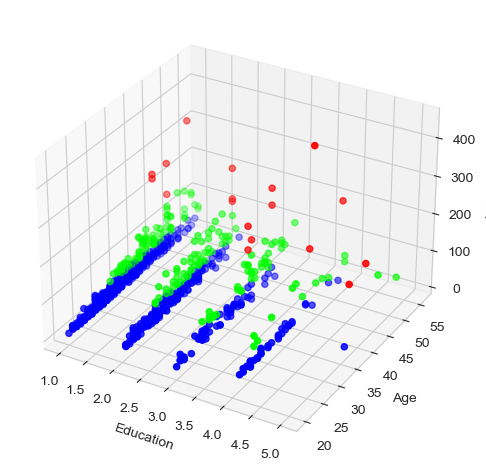

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df["Edu"], df["Age"], df["Income"], c=df["Label"], cmap="brg")
ax.set_xlabel('Education')
ax.set_ylabel('Age')
ax.set_zlabel('Income')
plt.tight_layout()
plt.show()